In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter

df = pd.read_csv("gym_membership_renewal.csv")
df

,customer_id,age,gender,subscription_length,membership_type,num_logins,num_complaints,num_classes_attended,avg_session_time,renewed_membership
0,257561,56,Male,54,6,2,3,4,115.1,0
1,706964,69,Female,21,1,34,3,16,31.2,1
2,337298,46,Female,49,3,18,2,3,110.6,0
3,241148,32,Male,47,3,42,2,0,91.2,1
4,333758,60,Male,6,3,28,0,5,75.2,0
...,...,...,...,...,...,...,...,...,...,...
4995,580840,24,Male,12,12,24,3,1,53.8,0
4996,586340,66,Female,48,12,27,2,14,35.4,1
4997,690497,26,Female,31,6,12,4,18,30.2,1
4998,716043,53,Female,44,1,14,0,16,111.4,1


In [2]:
selected_cols = ["age", "gender", "subscription_length", "membership_type", "num_logins", "num_complaints", 
                 "num_classes_attended","avg_session_time", "renewed_membership"] 
missing_counts = df[selected_cols].isnull().sum()
print(missing_counts)

age                     0
gender                  0
subscription_length     0
membership_type         0
num_logins              0
num_complaints          0
num_classes_attended    0
avg_session_time        0
renewed_membership      0
dtype: int64


In [5]:
df["female"] = df["gender"].map({"Female": 1, "Male": 0}) # Zmiana kolumny na ilościową
df["churn"] = 1 - df["renewed_membership"] # Kolumna "churn" jest odwrotnością "renewed_membership"
variables = ["age", "female", "num_logins", "num_complaints", "num_classes_attended",
             "avg_session_time", "membership_type"]


In [17]:
cph = CoxPHFitter()
cph.fit(df[variables + ["subscription_length", "churn"]], duration_col="subscription_length", event_col="churn")
cph.print_summary(model = "base_model", decimals=3)

<lifelines.CoxPHFitter: fitted with 5000 total observations, 3092 right-censored observations>
             duration col = 'subscription_length'
                event col = 'churn'
      baseline estimation = breslow
   number of observations = 5000
number of events observed = 1908
   partial log-likelihood = -14540.218
         time fit was run = 2026-06-02 01:34:38 UTC
                    model = base_model

---
                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                              
age                  -0.000     1.000     0.002          -0.003           0.003               0.997               1.003
female               -0.060     0.941     0.046          -0.150           0.030               0.861               1.030
num_logins           -0.015     0.985     0.002          -0.019          -0.012               0.982               0.988
num_complaints        0.083     1.087     0.017           0.051           0.116               1.052               1.123
num_classes_attended -0.040     0.961     0.004          -0.048          -0.032               0.953               0.969
avg_session_time      0.001     1.001     0.001          -0.001           0.003               0.999               1.003
membership_type       0.001     1.001     0.006          -0.010           0.012               0.990               1.012

                      cmp to      z       p  -log2(p)
covariate                                            
age                    0.000 -0.083   0.934     0.099
female                 0.000 -1.314   0.189     2.406
num_logins             0.000 -9.642 <0.0005    70.670
num_complaints         0.000  5.002 <0.0005    20.747
num_classes_attended   0.000 -9.691 <0.0005    71.368
avg_session_time       0.000  0.929   0.353     1.503
membership_type        0.000  0.226   0.821     0.285
---
Concordance = 0.586
Partial AIC = 29094.437
log-likelihood ratio test = 221.072 on 7 df
-log2(p) of ll-ratio test = 144.199


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'age' failed the non-proportional test: p-value is 0.0320.

   Advice 1: the functional form of the variable 'age' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'age' using pd.cut, and then specify it in `strata=['age',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


2. Variable 'num_logins' failed the non-proportional test: p-value is 0.0296.

   Advice 1: the functional form of the variable 'num_logins' might be incorrect. That is, there may
be non-linear terms missing. The proportional hazard test used is very sensitive to in

[[<Axes: xlabel='rank-transformed time\n(p=0.0320)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0670)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.8519)'>,
  <Axes: xlabel='km-transformed time\n(p=0.6868)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0296)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2177)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0324)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1013)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0056)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0143)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.1800)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1971)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.2692)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2174)'>]]

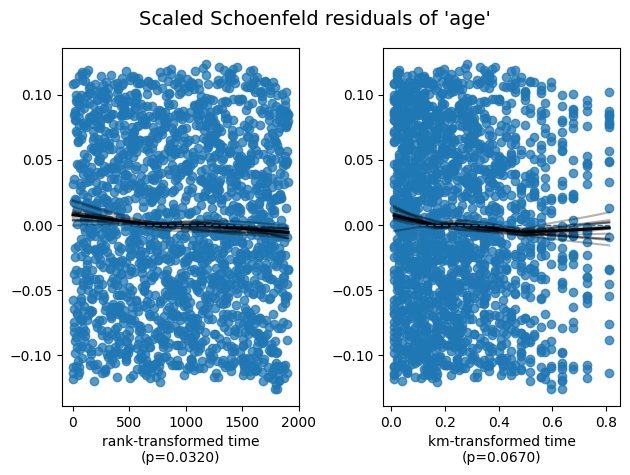

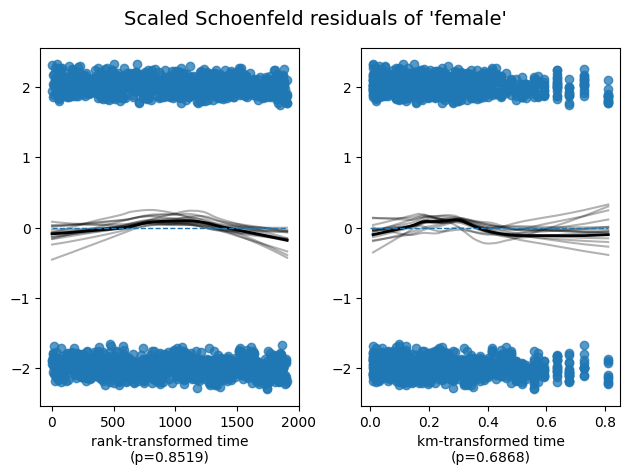

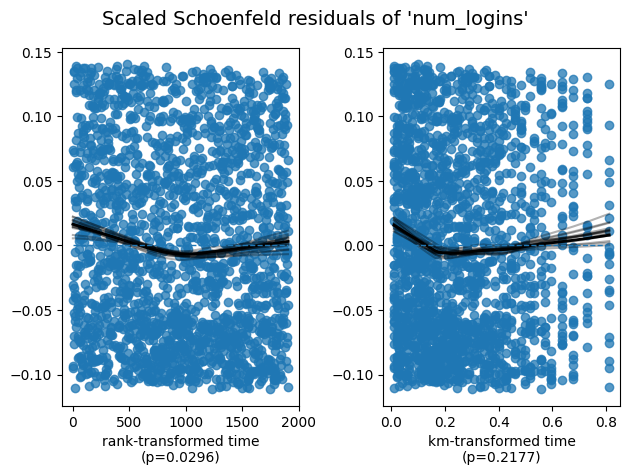

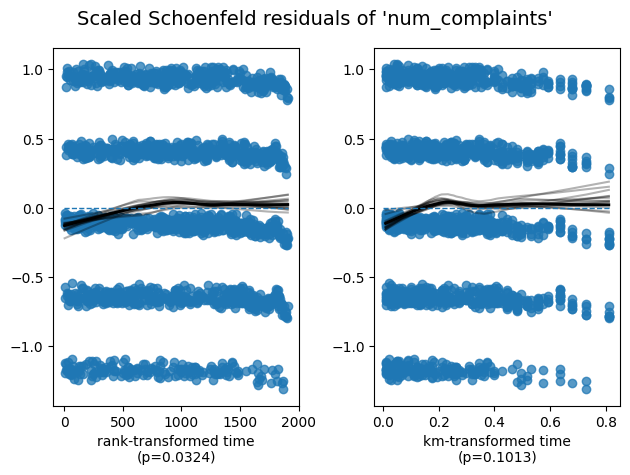

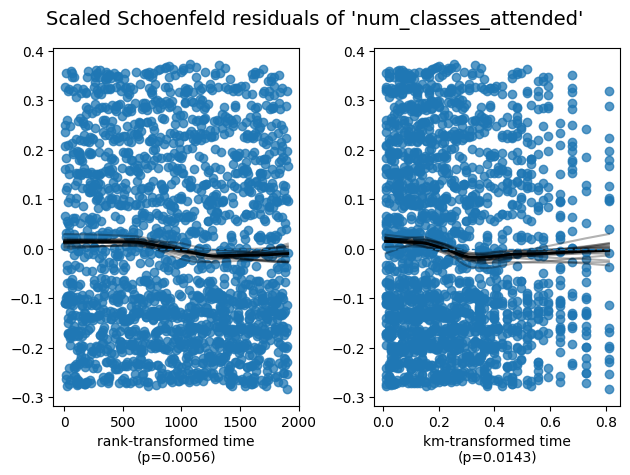

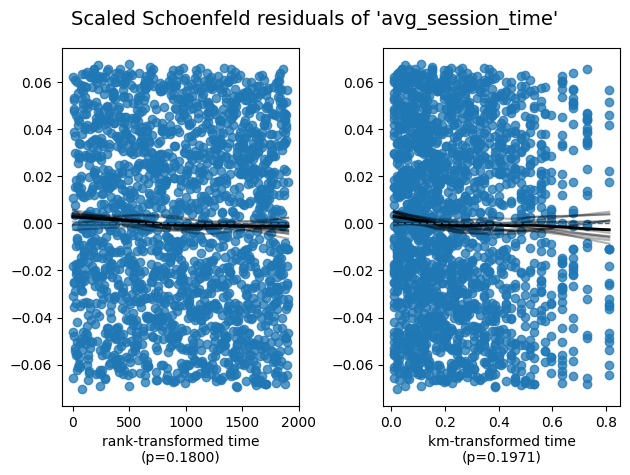

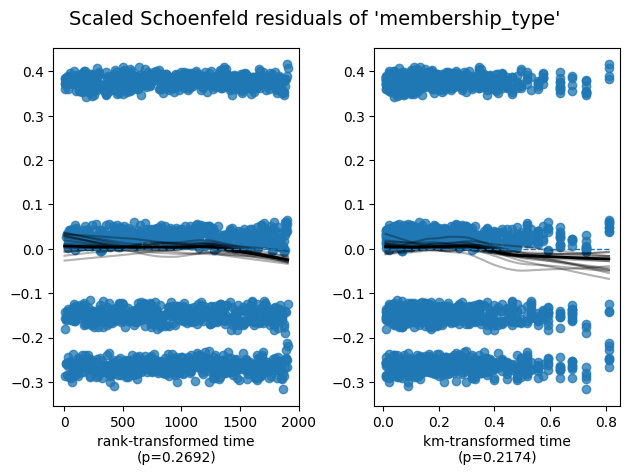

In [18]:
# Sprawdzanie założeń modelu Coxa
cph.check_assumptions(df[variables + ["subscription_length", "churn"]], p_value_threshold=0.05, show_plots=True)

In [63]:
print(df['membership_type'].unique())

[ 6  1  3 12]


In [64]:
cph.fit(df[variables + ["subscription_length", "churn"]], duration_col="subscription_length", event_col="churn", strata=["membership_type"])
cph.print_summary(model = "with interaction", decimals=3)

<lifelines.CoxPHFitter: fitted with 5000 total observations, 3092 right-censored observations>
             duration col = 'subscription_length'
                event col = 'churn'
                   strata = membership_type
      baseline estimation = breslow
   number of observations = 5000
number of events observed = 1908
   partial log-likelihood = -11900.308
         time fit was run = 2026-05-16 14:49:08 UTC
                    model = with interaction

---
                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                              
age                  -0.000     1.000     0.002          -0.003           0.003               0.997               1.003
female               -0.061     0.941     0.046          -0.151           0.029               0.860               1.030
num_logins           -0.015     0.985     0.002          -0.018          -0.012               0.982               0.988
num_complaints        0.083     1.086     0.017           0.050           0.115               1.051               1.122
num_classes_attended -0.040     0.961     0.004          -0.048          -0.032               0.953               0.969
avg_session_time      0.001     1.001     0.001          -0.001           0.003               0.999               1.003

                      cmp to      z       p  -log2(p)
covariate                                            
age                    0.000 -0.076   0.940     0.090
female                 0.000 -1.325   0.185     2.433
num_logins             0.000 -9.454 <0.0005    68.054
num_complaints         0.000  4.954 <0.0005    20.393
num_classes_attended   0.000 -9.611 <0.0005    70.240
avg_session_time       0.000  0.955   0.339     1.559
---
Concordance = 0.586
Partial AIC = 23812.615
log-likelihood ratio test = 215.527 on 6 df
-log2(p) of ll-ratio test = 142.939

In [15]:
from lifelines import CoxTimeVaryingFitter
from lifelines.utils import to_episodic_format

df_long = to_episodic_format(
    df[variables + ["subscription_length", "churn"]], 
    duration_col="subscription_length", 
    event_col="churn",
    time_gaps=1.0
)
df_long['time*age'] = df_long['age'] * df_long['stop']
df_long['time*num_classes'] = df_long['num_classes_attended'] * df_long['stop']
df_long['time*num_logins'] = df_long['num_logins'] * df_long['stop']
df_long['time*num_complaints'] = df_long['num_complaints'] * df_long['stop']

print(df_long.head(20))

    stop  start  churn  age  avg_session_time  female  id  membership_type  \
0    1.0    0.0      0   56             115.1       0   0                6   
1    2.0    1.0      0   56             115.1       0   0                6   
2    3.0    2.0      0   56             115.1       0   0                6   
3    4.0    3.0      0   56             115.1       0   0                6   
4    5.0    4.0      0   56             115.1       0   0                6   
5    6.0    5.0      0   56             115.1       0   0                6   
6    7.0    6.0      0   56             115.1       0   0                6   
7    8.0    7.0      0   56             115.1       0   0                6   
8    9.0    8.0      0   56             115.1       0   0                6   
9   10.0    9.0      0   56             115.1       0   0                6   
10  11.0   10.0      0   56             115.1       0   0                6   
11  12.0   11.0      0   56             115.1       0   0       

In [16]:
ctv = CoxTimeVaryingFitter()
ctv.fit(df_long, id_col="id", start_col="start", stop_col="stop", event_col="churn", strata=["membership_type"])
ctv.print_summary(model = "with interaction", decimals=3)

<lifelines.CoxTimeVaryingFitter: fitted with 150852 periods, 5000 subjects, 1908 events>
         event col = 'churn'
            strata = membership_type
number of subjects = 5000
 number of periods = 150852
  number of events = 1908
partial log-likelihood = -11891.012
  time fit was run = 2026-06-02 01:17:28 UTC
             model = with interaction

---
                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                              
age                   0.005     1.005     0.003          -0.001           0.010               0.999               1.010
avg_session_time      0.001     1.001     0.001          -0.001           0.003               0.999               1.003
female               -0.056     0.945     0.046          -0.147           0.034               0.864               1.034
num_classes_attended -0.023     0.977     0.007          -0.038          -0.009               0.963               0.991
num_complaints        0.036     1.037     0.030          -0.022           0.095               0.978               1.100
num_logins           -0.011     0.989     0.003          -0.017          -0.005               0.983               0.995
time*age             -0.000     1.000     0.000          -0.000          -0.000               1.000               1.000
time*num_classes     -0.001     0.999     0.000          -0.001          -0.000               0.999               1.000
time*num_logins      -0.000     1.000     0.000          -0.000           0.000               1.000               1.000
time*num_complaints   0.002     1.002     0.001          -0.000           0.004               1.000               1.004

                      cmp to      z       p  -log2(p)
covariate                                            
age                    0.000  1.720   0.085     3.549
avg_session_time       0.000  0.910   0.363     1.463
female                 0.000 -1.228   0.219     2.189
num_classes_attended   0.000 -3.135   0.002     9.184
num_complaints         0.000  1.210   0.226     2.145
num_logins             0.000 -3.830 <0.0005    12.928
time*age               0.000 -2.127   0.033     4.902
time*num_classes       0.000 -2.679   0.007     7.083
time*num_logins        0.000 -1.718   0.086     3.543
time*num_complaints    0.000  1.886   0.059     4.076
---
Partial AIC = 23802.024
log-likelihood ratio test = 234.118 on 10 df
-log2(p) of ll-ratio test = 145.932